# Analíse exploratória do "The Hot 100 Billboard" da última década



## 1) Importação de Libs + Limpeza Inicial

Como o dataset possui mais de 300 mil linhas, com dados desde o ano de 1958, optamos por utilizar somente as informações da década passada

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

plt.rcParams["date.autoformatter.day"] = "%d/%m/%Y"

In [43]:
base = r'charts.csv'
charts = pd.read_csv(base)
charts = charts.rename(columns={"date": "Data", "rank": "Ranking", "song": "Música", "artist": "Artista", "last-week": "Última Semana", "peak-rank": "Maior Posição", "weeks-on-board": "Semanas no Board"})
charts["Data"] = pd.to_datetime(charts["Data"])
charts = charts[
    (charts["Data"].dt.year >= 2011)
]
charts.head()

,Data,Ranking,Música,Artista,Última Semana,Maior Posição,Semanas no Board
0,2021-11-06,1,Easy On Me,Adele,1.0,1,3
1,2021-11-06,2,Stay,The Kid LAROI & Justin Bieber,2.0,1,16
2,2021-11-06,3,Industry Baby,Lil Nas X & Jack Harlow,3.0,1,14
3,2021-11-06,4,Fancy Like,Walker Hayes,4.0,3,19
4,2021-11-06,5,Bad Habits,Ed Sheeran,5.0,2,18


In [44]:
print("Dimensões do dataset:")
print(charts.shape)

print("\nInformações das colunas:")
charts.info()

print('\nQuantidade de nulls em porcentagem (%)')
print((charts.isnull().mean() * 100).round(2))

Dimensões do dataset:
(56700, 7)

Informações das colunas:
<class 'pandas.DataFrame'>
RangeIndex: 56700 entries, 0 to 56699
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Data              56700 non-null  datetime64[us]
 1   Ranking           56700 non-null  int64         
 2   Música            56700 non-null  str           
 3   Artista           56700 non-null  str           
 4   Última Semana     50120 non-null  float64       
 5   Maior Posição     56700 non-null  int64         
 6   Semanas no Board  56700 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 3.0 MB

Quantidade de nulls em porcentagem (%)
Data                 0.0
Ranking              0.0
Música               0.0
Artista              0.0
Última Semana       11.6
Maior Posição        0.0
Semanas no Board     0.0
dtype: float64


## Informações gerais do dataset

In [45]:
charts.describe()
charts.mode(numeric_only=True).iloc[0]

Ranking             1.0
Última Semana       5.0
Maior Posição       1.0
Semanas no Board    1.0
Name: 0, dtype: float64

In [46]:
print("Ranking mínimo:", charts["Ranking"].min())
print("Ranking máximo:", charts["Ranking"].max())

Ranking mínimo: 1
Ranking máximo: 100


In [47]:
charts[
    (charts["Maior Posição"] < 1) |
    (charts["Maior Posição"] > 100)
]

,Data,Ranking,Música,Artista,Última Semana,Maior Posição,Semanas no Board


In [48]:
Q1 = charts["Semanas no Board"].quantile(0.25)
Q3 = charts["Semanas no Board"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = charts[
    (charts["Semanas no Board"] < limite_inferior) |
    (charts["Semanas no Board"] > limite_superior)
]

print("Quantidade de possíveis outliers:", len(outliers))

Quantidade de possíveis outliers: 2014


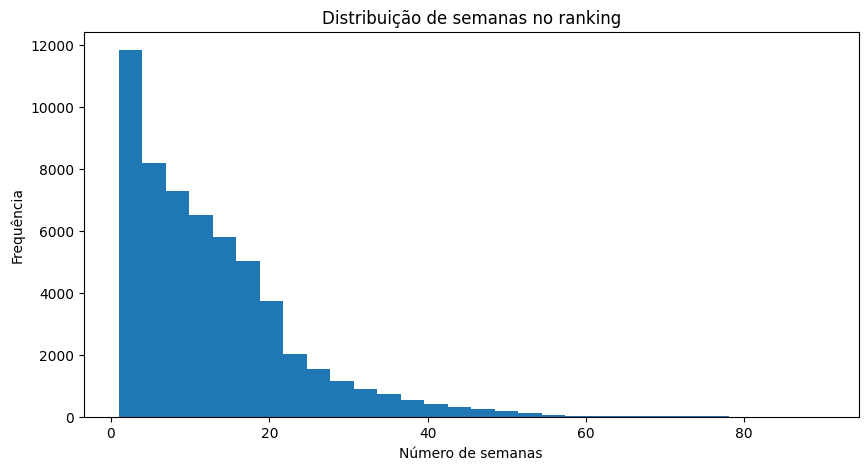

In [49]:
plt.figure(figsize=(10, 5))

plt.hist(
    charts["Semanas no Board"],
    bins=30
)

plt.title("Distribuição de semanas no ranking")
plt.xlabel("Número de semanas")
plt.ylabel("Frequência")

plt.show()

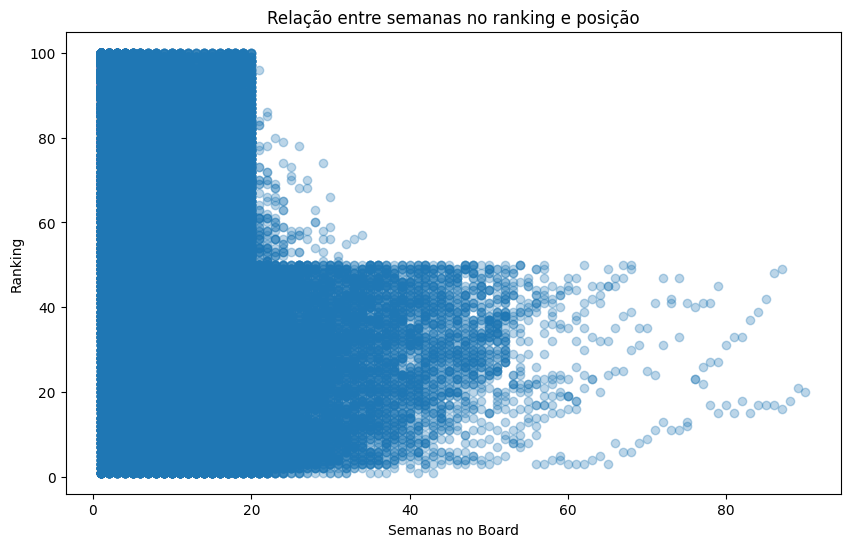

In [50]:
plt.figure(figsize=(10, 6))

plt.scatter(
    charts["Semanas no Board"],
    charts["Ranking"],
    alpha=0.3
)

plt.title("Relação entre semanas no ranking e posição")
plt.xlabel("Semanas no Board")
plt.ylabel("Ranking")

plt.show()

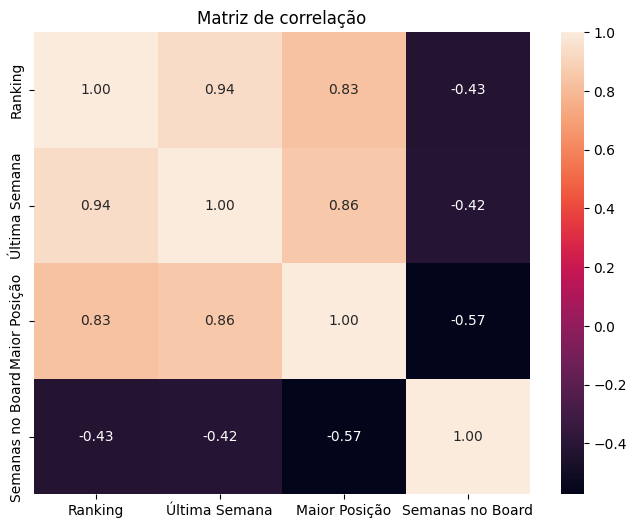

In [51]:
correlacao = charts[
    ["Ranking", "Última Semana", "Maior Posição", "Semanas no Board"]
].corr()

correlacao
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlação")

plt.show()

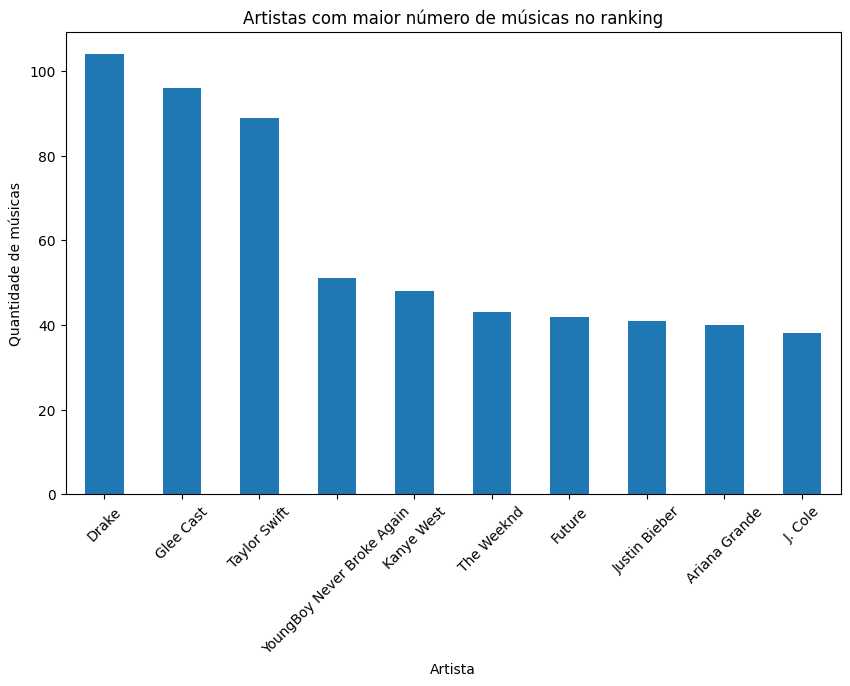

In [52]:
musicas_por_artista = (
    charts.groupby("Artista")["Música"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
musicas_por_artista.plot(kind="bar")
plt.title("Artistas com maior número de músicas no ranking")
plt.xlabel("Artista")
plt.ylabel("Quantidade de músicas")

plt.xticks(rotation=45)
plt.show()

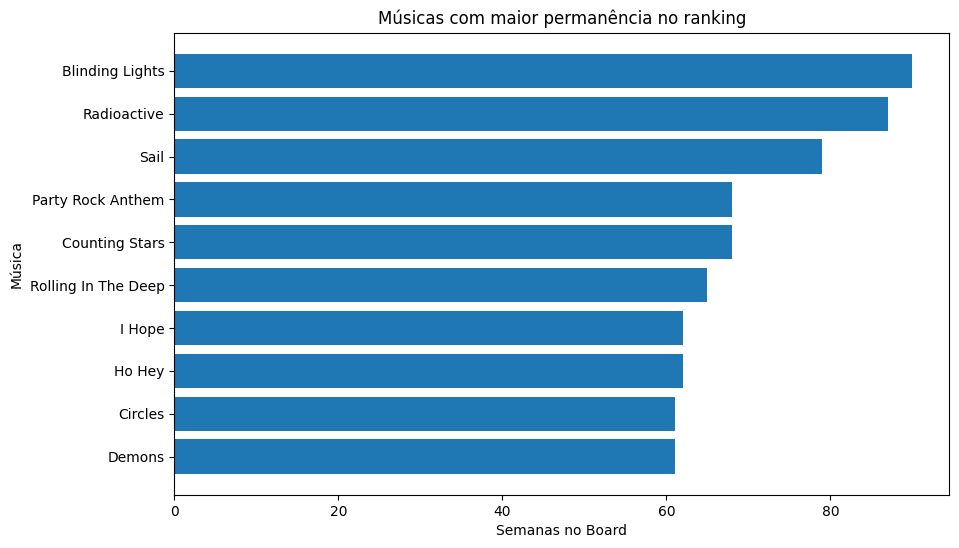

In [55]:
top_musicas = (
    charts.groupby(["Música", "Artista"])["Semanas no Board"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_musicas["Música"],
    top_musicas["Semanas no Board"]
)

plt.title("Músicas com maior permanência no ranking")
plt.xlabel("Semanas no Board")
plt.ylabel("Música")

plt.gca().invert_yaxis()

plt.show()

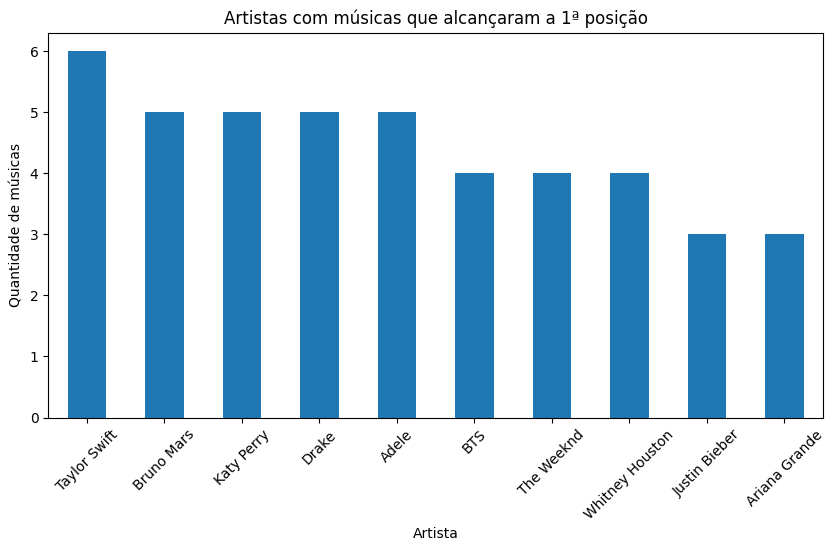

In [56]:
numero_1 = charts[charts["Maior Posição"] == 1]

artistas_numero_1 = (
    numero_1.groupby("Artista")["Música"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
artistas_numero_1.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Artistas com músicas que alcançaram a 1ª posição")
plt.xlabel("Artista")
plt.ylabel("Quantidade de músicas")

plt.xticks(rotation=45)
plt.show()

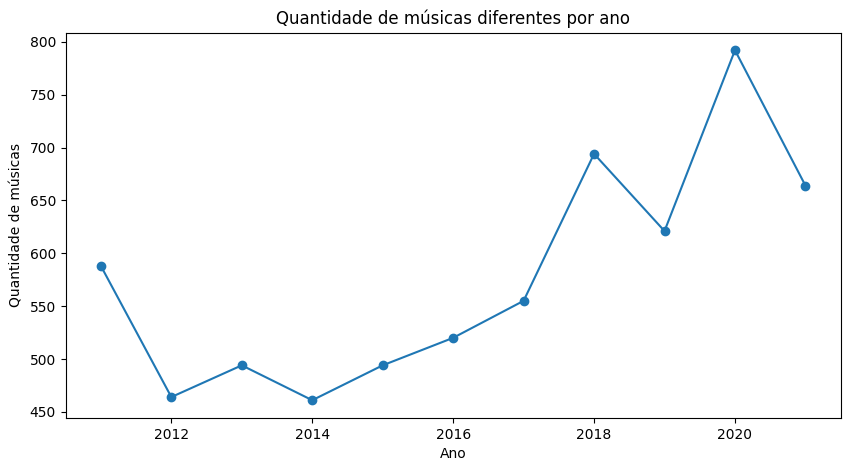

In [57]:
musicas_por_ano = (
    charts.groupby(charts["Data"].dt.year)["Música"]
    .nunique()
)
plt.figure(figsize=(10, 5))

musicas_por_ano.plot(kind="line", marker="o")

plt.title("Quantidade de músicas diferentes por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de músicas")

plt.show()